<a href="https://colab.research.google.com/github/AzmiFH/api_model-smarbite/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from google.colab import drive
# Gunakan force_remount=True untuk menyegarkan koneksi yang gagal
drive.mount('/content/drive', force_remount=True)

import os
import cv2
import imghdr
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

Mounted at /content/drive


# Cleaning Images

In [27]:
data_dir = '/content/drive/MyDrive/skripsi/dataset/Images/'

In [28]:
image_extensions = ['jpg', 'jpeg', 'png', 'bmp']

In [29]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            image_type = imghdr.what(image_path)
            if image_type not in image_extensions:
                print(f'{image_path} is not a valid image')
                os.remove(image_path)
        except Exception as e:
            print(f'Error processing {image_path}: {e}')

# Data Preprocessing

In [30]:
data = tf.keras.utils.image_dataset_from_directory(data_dir)

Found 6443 files belonging to 17 classes.


In [31]:
data_iterators = data.as_numpy_iterator()
batch = next(data_iterators)
batch[1].max()


np.int32(16)

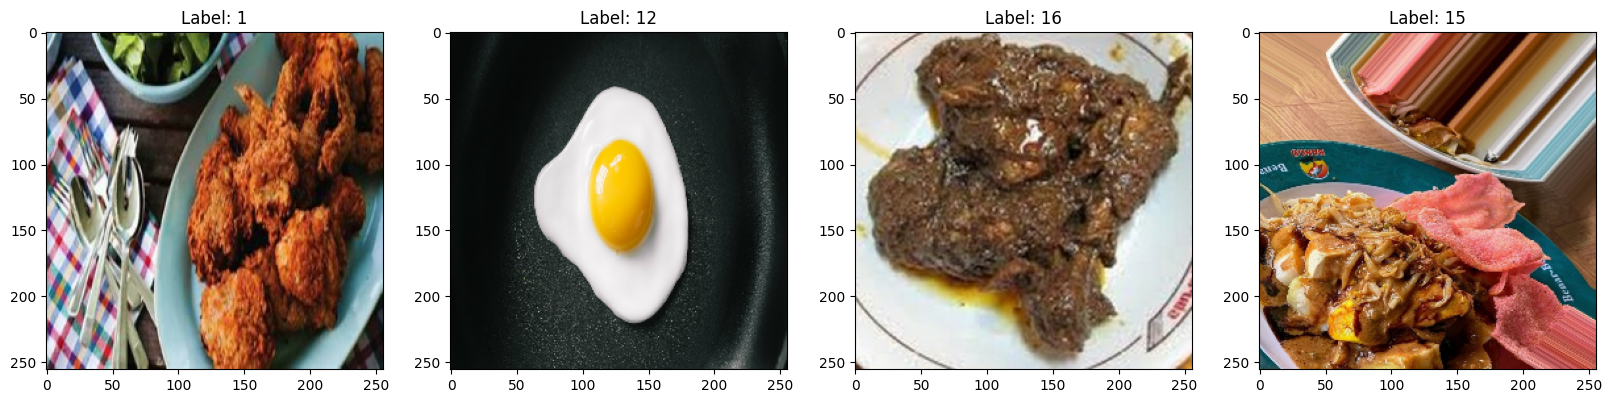

In [32]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, image in enumerate(batch[0][:4]):
    ax[idx].imshow(image.astype(int))
    ax[idx].title.set_text(f'Label: {batch[1][idx]}')

In [33]:
from pathlib import Path
import pandas as pd
import os

data_dir = '/content/drive/MyDrive/skripsi/dataset/Images/'
data_dir_path = Path(data_dir)

# PERBAIKAN: Mengambil gambar .jpg, .jpeg, dan .png sekaligus
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
filepaths = []
for ext in image_extensions:
    filepaths.extend(list(data_dir_path.glob(f'**/{ext}')))

labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

images = pd.concat([filepaths, labels], axis=1)

category_samples = []
for category in images['Label'].unique():
    category_slice = images.query("Label == @category")
    max_sample = min(300, len(category_slice))  # Membatasi maksimal 300 gambar
    category_samples.append(category_slice.sample(max_sample, random_state=1))

image_df = pd.concat(category_samples, axis=0).sample(frac=1.0, random_state=1).reset_index(drop=True)

# Mengecek apakah 17 folder sudah terbaca semua
print(f"Total gambar yang berhasil dimuat: {len(image_df)}")
print(f"Total kategori makanan: {len(image_df['Label'].unique())}")

Total gambar yang berhasil dimuat: 5093
Total kategori makanan: 17


In [34]:
image_df['Label'].value_counts()

,count
Label,
Bawang Bombai,300
Alpukat,300
Mangga,300
Nasi Putih,300
Bawang Merah,300
Bawang Putih,300
Tempe Goreng,300
es krim,300
Sate Ayam,300


Split Data

In [35]:
train_df, test_df = train_test_split(
    image_df,
    train_size=0.8,
    shuffle=True,
    random_state=1)

In [36]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [37]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 3260 validated image filenames belonging to 17 classes.
Found 814 validated image filenames belonging to 17 classes.
Found 1019 validated image filenames belonging to 17 classes.


# Pre-Trained

In [38]:
from tensorflow.keras.regularizers import l2

res_base = tf.keras.applications.ResNet152V2(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))
res_base.trainable = False

inputs = res_base.input

x = res_base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(256, activation='leaky_relu', kernel_regularizer=l2(0.001))(x)
outputs = tf.keras.layers.Dense(17, activation='softmax', kernel_regularizer=l2(0.001))(x)
model = tf.keras.Model(inputs, outputs)
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 7, 7, 2048)     │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,516,433 (227.04 MB)

 Trainable params: 1,184,785 (4.52 MB)

 Non-trainable params: 58,331,648 (222.52 MB)

None


# Training

In [39]:
from tensorflow.keras.optimizers import Adamax

# Compile the model
model.compile(optimizer=Adamax(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [40]:
# Define callbacks for early stopping and model checkpoint
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('/content/drive/MyDrive/skripsi/model_backup/best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# Train the model with frozen layers
history1 = model.fit(train_images, epochs=30, verbose=1, validation_data=val_images, callbacks=callbacks, shuffle=False)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.4814 - loss: 2.9026
Epoch 1: val_loss improved from None to 1.54717, saving model to /content/drive/MyDrive/skripsi/model_backup/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skripsi/model_backup/best_model.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 107s 778ms/step - accuracy: 0.6350 - loss: 2.3122 - val_accuracy: 0.8403 - val_loss: 1.5472
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8187 - loss: 1.6439
Epoch 2: val_loss improved from 1.54717 to 1.37374, saving model to /content/drive/MyDrive/skripsi/model_backup/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/skripsi/model_backup/best_model.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 60s 584ms/step - accuracy: 0.8331 - loss: 1.5794 - val_accuracy: 0.8784 - val_loss: 1.3737
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8844 - loss: 1.3935
Epoch 3: val_loss improved from 1.37374 to 1.32098, saving 

In [41]:
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Accuracy: 91.66%


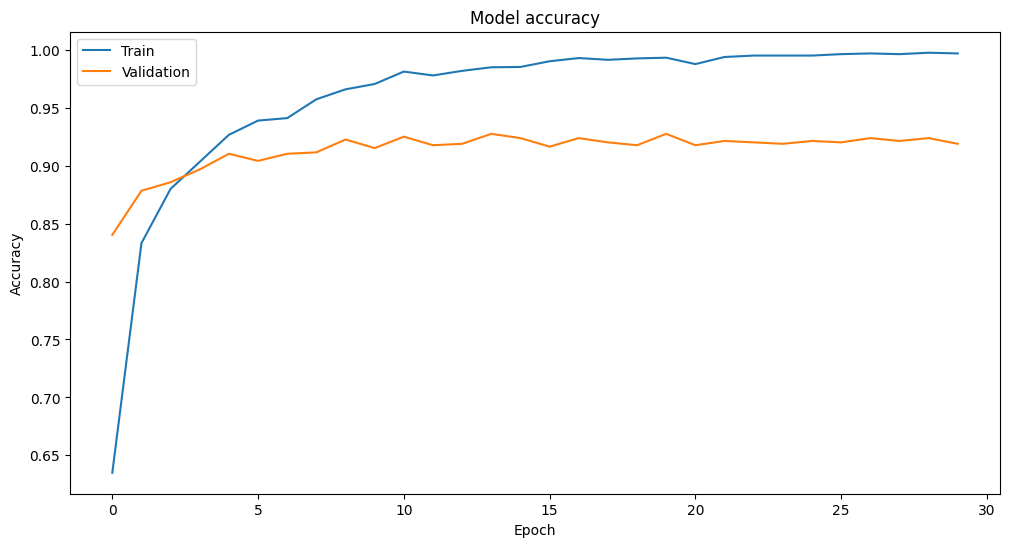

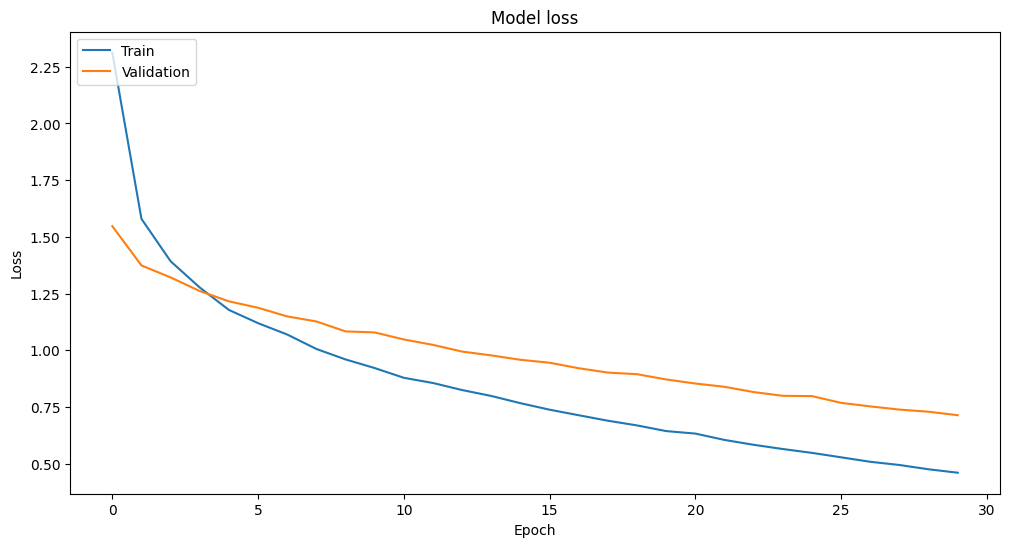

In [42]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 700ms/step


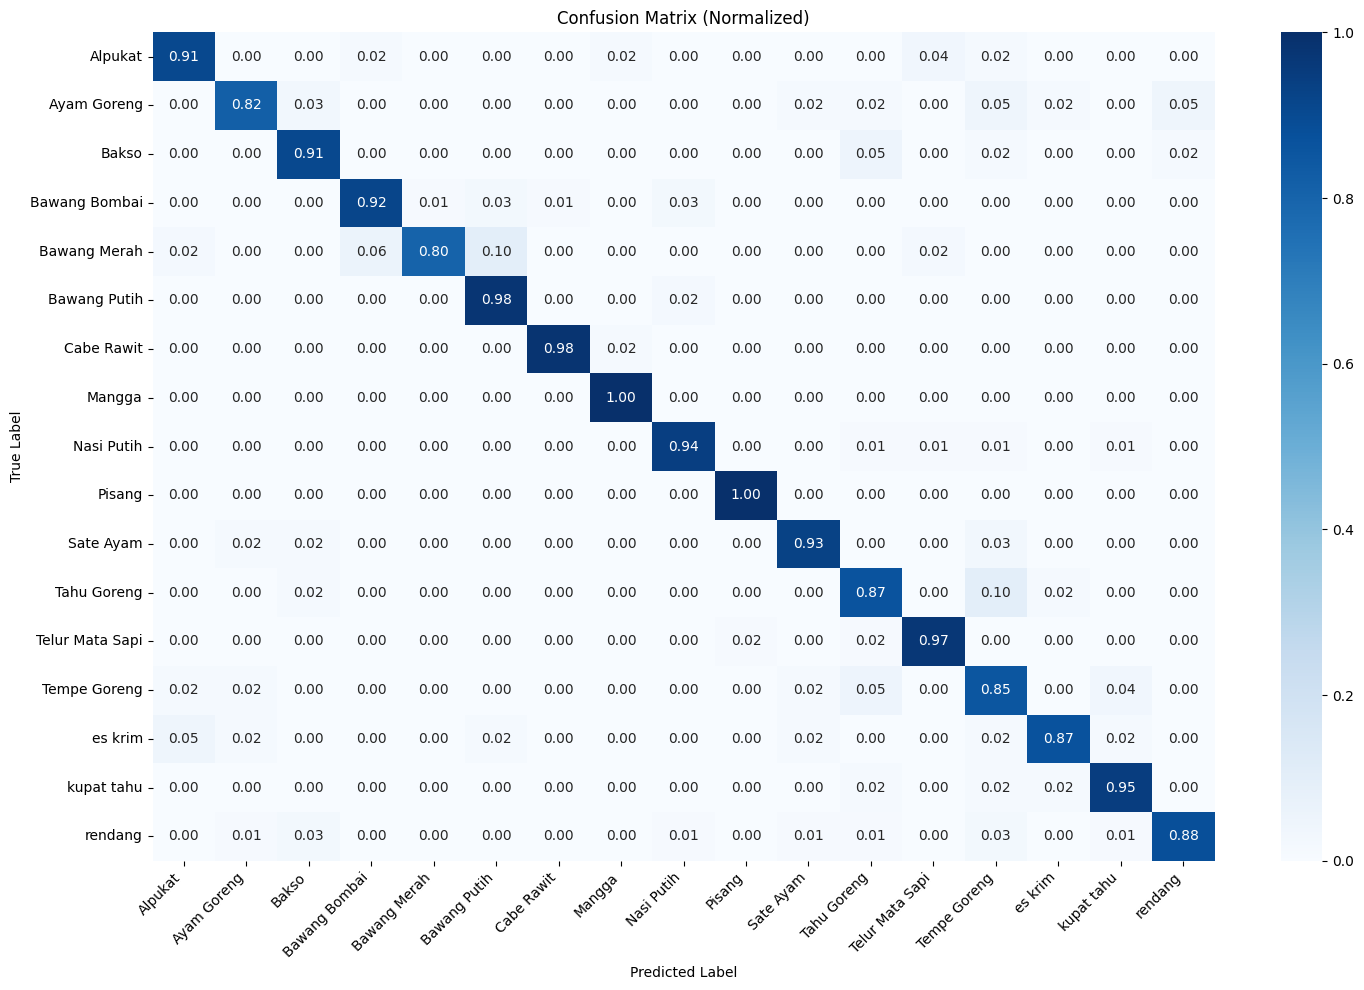


Classification Report:
                 precision    recall  f1-score   support

        Alpukat       0.91      0.91      0.91        55
    Ayam Goreng       0.92      0.82      0.87        60
          Bakso       0.89      0.91      0.90        55
  Bawang Bombai       0.94      0.92      0.93        74
   Bawang Merah       0.98      0.80      0.88        51
   Bawang Putih       0.85      0.98      0.91        48
     Cabe Rawit       0.98      0.98      0.98        55
         Mangga       0.97      1.00      0.98        57
     Nasi Putih       0.94      0.94      0.94        71
         Pisang       0.98      1.00      0.99        61
      Sate Ayam       0.93      0.93      0.93        59
    Tahu Goreng       0.83      0.87      0.85        60
Telur Mata Sapi       0.94      0.97      0.95        65
   Tempe Goreng       0.72      0.85      0.78        55
        es krim       0.95      0.87      0.91        62
     kupat tahu       0.91      0.95      0.93        56
      

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(
    model,
    test_generator,
    class_names=None,
    title='Confusion Matrix',
    normalize=True
):
    """
    Fungsi untuk membuat dan memvisualisasikan Confusion Matrix

    Parameters:
    - model: Model yang sudah dilatih
    - test_generator: Generator data test
    - class_names: Nama-nama kelas
    - normalize: Apakah matrix dinormalisasi
    """

    # Reset generator
    test_generator.reset()

    # Ambil semua data test
    y_true = test_generator.classes

    # Prediksi menggunakan model
    y_pred = model.predict(test_generator)

    # Konversi prediksi ke kelas
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Jika class_names tidak disediakan, gunakan indeks kelas
    if class_names is None:
        class_names = list(test_generator.class_indices.keys())

    # Hitung confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)

    # Normalisasi jika diminta
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
        title += ' (Normalized)'
    else:
        fmt = 'd'

    # Visualisasi
    plt.figure(figsize=(15, 10))

    # Confusion Matrix Heatmap
    sns.heatmap(
        cm,
        annot=True,
        cmap='Blues',
        fmt=fmt,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Cetak classification report
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names
    ))

def advanced_confusion_matrix_analysis(
    model,
    test_generator,
    class_names=None
):
    """
    Analisis mendalam Confusion Matrix
    """
    # Reset generator
    test_generator.reset()

    # Ambil semua data test
    y_true = test_generator.classes

    # Prediksi menggunakan model
    y_pred = model.predict(test_generator)

    # Konversi prediksi ke kelas
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Jika class_names tidak disediakan, gunakan indeks kelas
    if class_names is None:
        class_names = list(test_generator.class_indices.keys())

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_classes)

    # Visualisasi Detail
    plt.figure(figsize=(20, 15))

    # Subplot 1: Normalized Confusion Matrix
    plt.subplot(2, 2, 1)
    sns.heatmap(
        cm.astype('float') / cm.sum(axis=1)[:, np.newaxis],
        annot=True,
        cmap='Blues',
        fmt='.2f',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')

    # Subplot 2: Raw Confusion Matrix
    plt.subplot(2, 2, 2)
    sns.heatmap(
        cm,
        annot=True,
        cmap='Reds',
        fmt='d',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title('Raw Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')

    # Subplot 3: Precision per Class
    precision_per_class = cm.diagonal() / cm.sum(axis=0)
    plt.subplot(2, 2, 3)
    plt.bar(class_names, precision_per_class)
    plt.title('Precision per Class')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Precision')

    # Subplot 4: Recall per Class
    recall_per_class = cm.diagonal() / cm.sum(axis=1)
    plt.subplot(2, 2, 4)
    plt.bar(class_names, recall_per_class)
    plt.title('Recall per Class')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Recall')

    plt.tight_layout()
    plt.show()

    # Identifikasi Kesalahan Terburuk
    misclassification_analysis(
        y_true,
        y_pred_classes,
        class_names
    )

def misclassification_analysis(
    y_true,
    y_pred,
    class_names,
    top_n=5
):
    """
    Analisis kesalahan klasifikasi terburuk
    """
    # Temukan indeks prediksi salah
    misclassified_indices = np.where(y_true != y_pred)[0]

    # Hitung frekuensi kesalahan
    misclass_freq = {}
    for true, pred in zip(y_true[misclassified_indices],
                          y_pred[misclassified_indices]):
        key = (class_names[true], class_names[pred])
        misclass_freq[key] = misclass_freq.get(key, 0) + 1

    # Urutkan kesalahan terburuk
    worst_misclassifications = sorted(
        misclass_freq.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    print("\nTop Worst Misclassifications:")
    for (true_class, pred_class), freq in worst_misclassifications:
        print(f"{true_class} misclassified as {pred_class}: {freq} times")

# Pastikan test_images adalah generator yang valid dan model adalah model yang sudah dilatih
# Misalnya:
# test_images = ImageDataGenerator().flow_from_directory('path_to_test_images')
# model = tf.keras.models.load_model('path_to_model')

# Cara Penggunaan
# Dapatkan nama kelas dari generator
class_names = list(test_images.class_indices.keys())

# Reset generator sebelum digunakan
test_images.reset()

# Plot Confusion Matrix
plot_confusion_matrix(
    model,
    test_images,
    class_names=class_names
)


# Prediction

In [44]:
import sys
sys.path.append('/content/drive/MyDrive/skripsi/dataset/file')

In [45]:
import os
# Cek apakah folder tersebut ada dan apa isinya
path_to_check = '/content/drive/MyDrive/skripsi/dataset/file'
if os.path.exists(path_to_check):
    print(f"Isi folder {path_to_check}:")
    print(os.listdir(path_to_check))
else:
    print(f"Folder {path_to_check} TIDAK ditemukan. Silakan periksa kembali jalurnya di Google Drive.")

Isi folder /content/drive/MyDrive/skripsi/dataset/file:
['prediction.py', 'csv_path.py', 'Preprocessing.py', '__pycache__']


🔍 Memproses gambar: /content/drive/MyDrive/skripsi/dataset/test/es.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


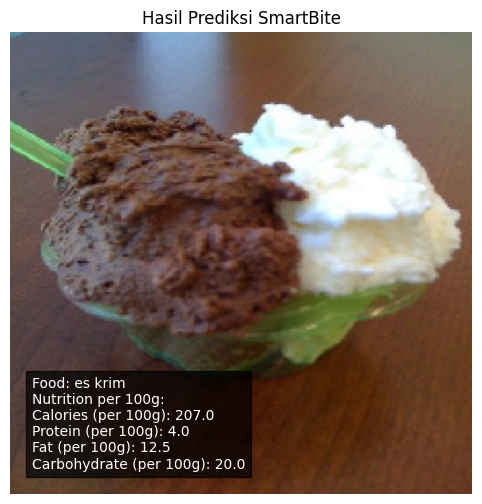

In [46]:
    import sys
    import os
    import tensorflow as tf
    import matplotlib.pyplot as plt
    import random

    # 1. Setup paths
    folder_path = '/content/drive/MyDrive/skripsi/dataset/file'
    if folder_path not in sys.path:
        sys.path.append(folder_path)

    # 2. IMPORT BIASA
    from prediction import predict_food
    from Preprocessing import train_images

    csv_path = '/content/drive/MyDrive/skripsi/dataset/Data/nutrition.csv'
    model_path = '/content/drive/MyDrive/skripsi/model_backup/smartbite.h5'
    test_image_path = '/content/drive/MyDrive/skripsi/dataset/test/es.jpg'

    # 3. Jalankan prediksi
    try:
        print(f"🔍 Memproses gambar: {test_image_path}")
        result = predict_food(test_image_path, model_path, csv_path,
  train_images.class_indices)

        # 4. Visualisasi
        img = tf.keras.preprocessing.image.load_img(test_image_path,
  target_size=(224, 224))
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title("Hasil Prediksi SmartBite")
        plt.axis('off')

        # Overlay text
        plt.text(10, 210, result, fontsize=10, color='white',
                 bbox=dict(facecolor='black', alpha=0.7), wrap=True)
        plt.show()

    except Exception as e:
        print(f"❌ Terjadi kesalahan: {e}")

In [47]:
model.save('/content/drive/MyDrive/skripsi/model_backup/smartbite.h5')